In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_deltaE_vs_deltaVrad(csv_path):
    # --- Load data ---
    df = pd.read_csv(csv_path)

    x = df["E_CT-S1"].values          # ΔE_{S1,CT}
    y = df["Delta_V_rad"].values      # ΔV_oc^{rad}
    names = df["Name"].values

    # --- Linear fit (y = m x + b) ---
    m, b = np.polyfit(x, y, 1)
    fit_x = np.linspace(0, x.max() * 1.1, 200)
    fit_y = m * fit_x + b

    # --- Intersection with y = 0.005 ---
    y_target = 0.005
    x_intersect = (y_target - b) / m

    # --- Plot --- 
    colors = ["#0b5394", "#d5a6bd", "#9467bd",'#ffbf00','#741b47', '#ff9100'] 
    marker_size = 80

    fig, ax = plt.subplots(figsize=(5, 4),dpi=400)

    # Data points (solid circles)
    ax.scatter(x, y,c=colors, s=marker_size, marker="o")

    # Text labels for each data point
    for xi, yi, label in zip(x, y, names):
        ax.text(xi + 0.005, yi + 0.01, label, fontsize=8)

    # Fitted line (dashed, #38761d)
    ax.plot(fit_x, fit_y, linestyle="--", linewidth=1.8, color="#38761d")

    # Horizontal dash-dot line at y = 0.005 (#3399cc)
    ax.axhline(y_target, color="#3399cc", linestyle="-.", linewidth=1.5)

    # Hollow circle at intersection (same size as other markers)
    ax.scatter(
        [x_intersect],
        [y_target],
        facecolors="none",
        edgecolors="#3399cc",
        s=marker_size,
        linewidths=2,
    )

    # Label next to the intersection point
    ax.text(x_intersect - 0.07, y_target + 0.01, "FBR|SubNc",
            color="black", fontsize=8)

    # Axis labels
    ax.set_xlabel(r"$\Delta E_{S1,CT}$ (eV)")
    ax.set_ylabel(r"$\Delta V_{oc}^{rad}$ (V)")

    # Axis limits starting from 0
    ax.set_xlim(0, x.max() * 1.1)
    ax.set_ylim(0, y.max() * 1.1)
    ax.minorticks_on()

    # Grid + layout
    #ax.grid(True)
    plt.tight_layout()
    
    plt.show()

    return fig, ax


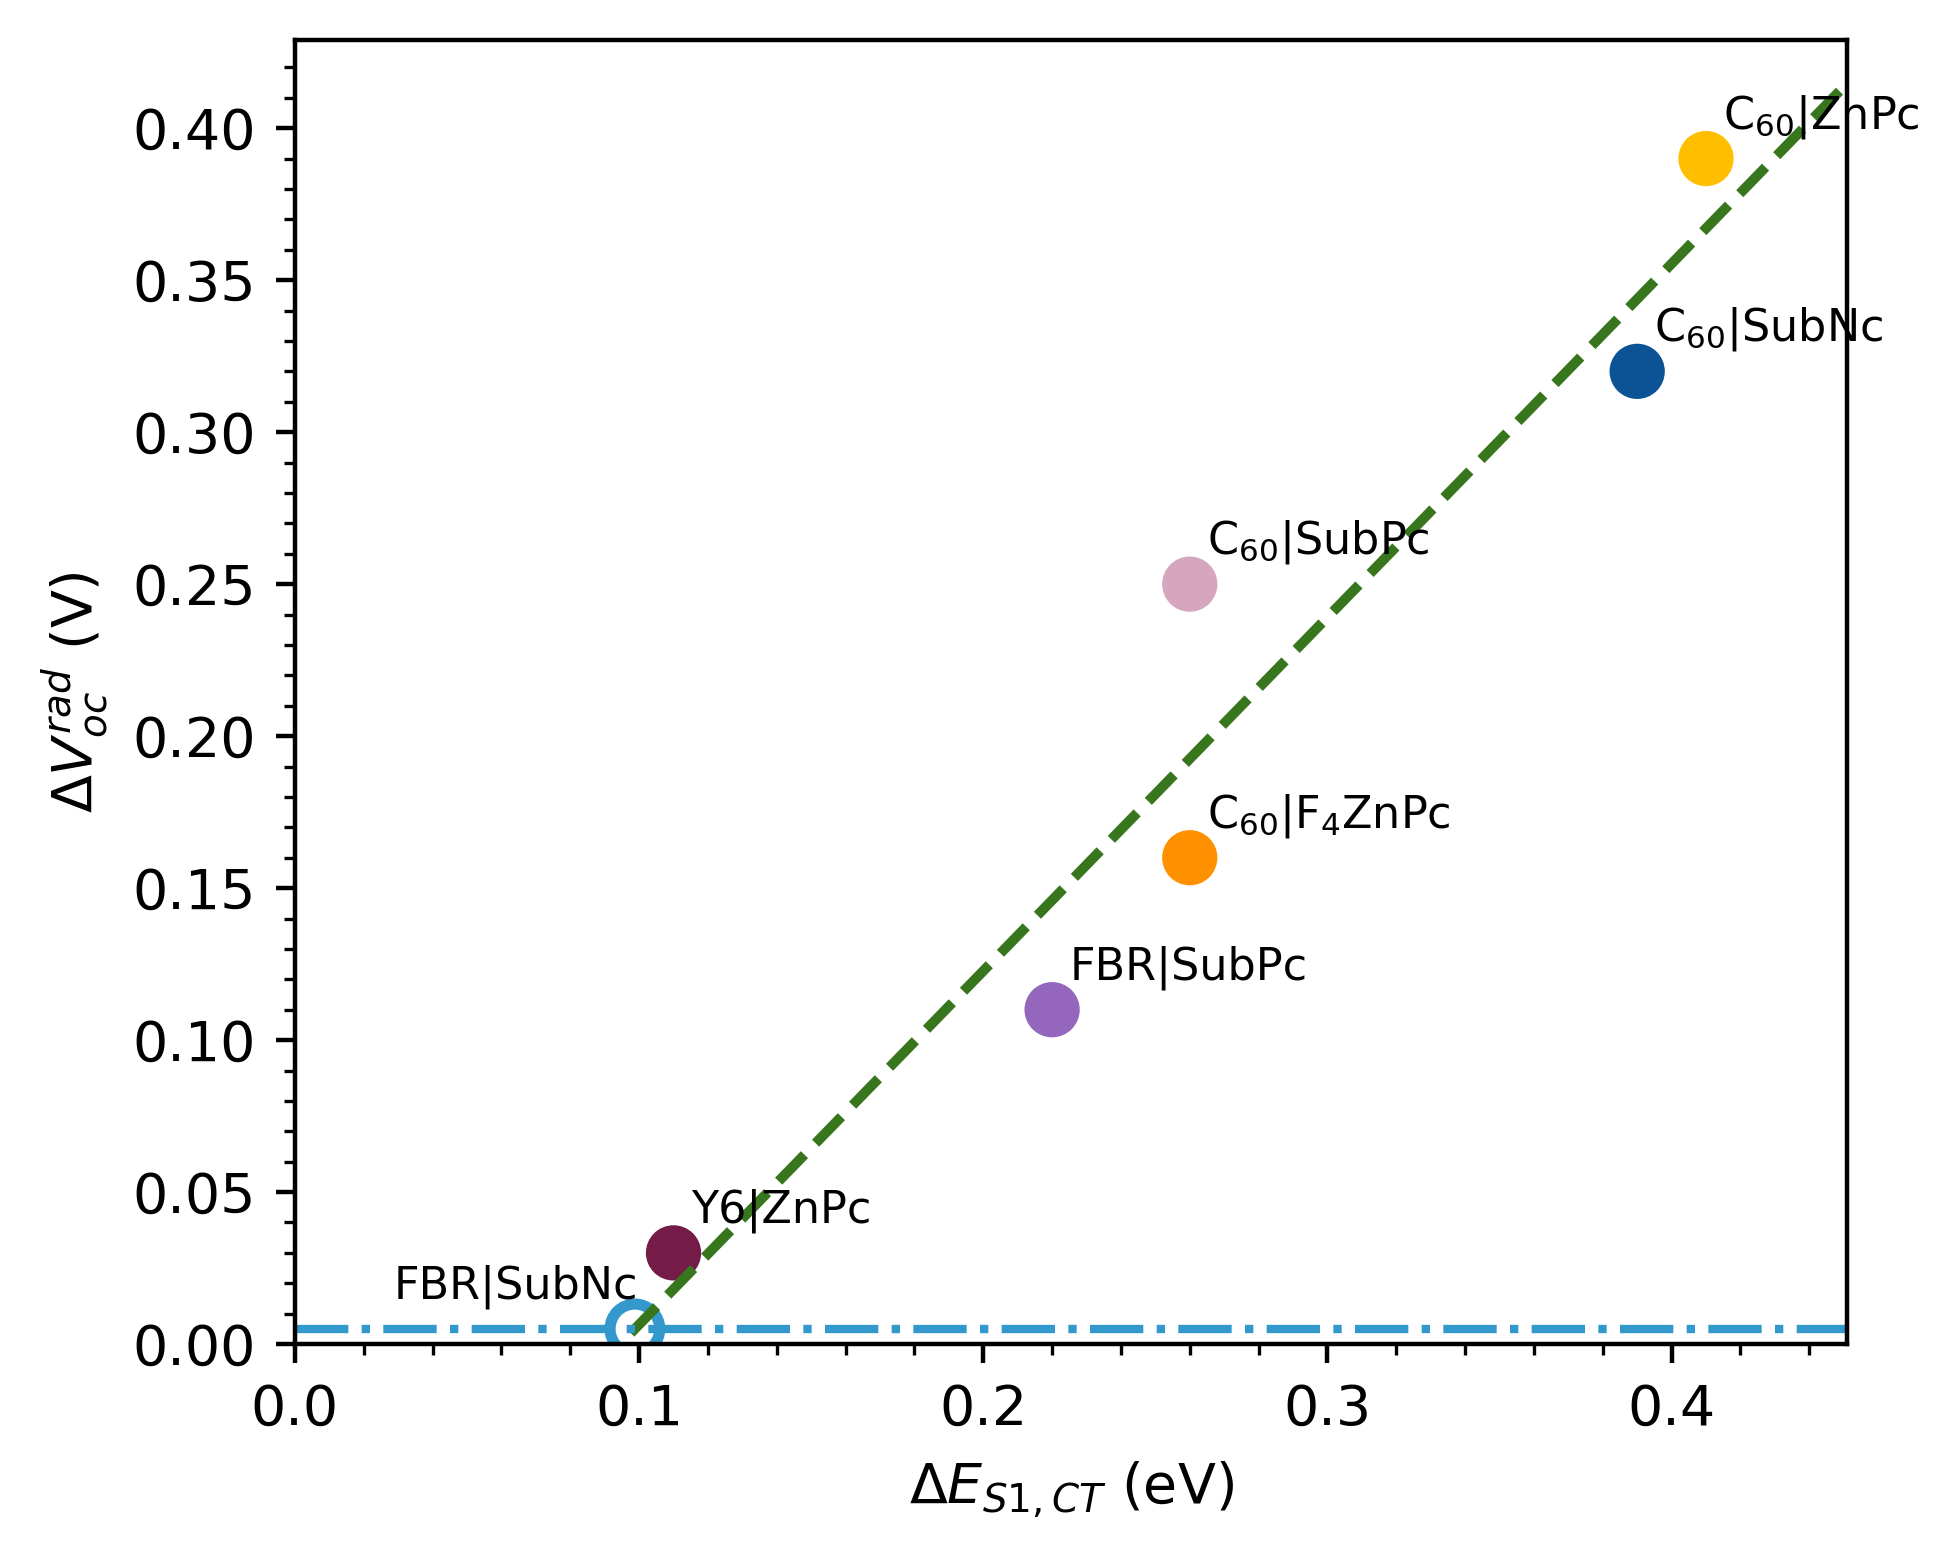

In [24]:
fig, ax = plot_deltaE_vs_deltaVrad("/Users/mingzhu/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Hybrid Project/DATA/Correlation/PHJ_Delta_ECT_Delta_Vrad.csv")
fig.savefig("/Users/mingzhu/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Hybrid Project/DATA/Correlation/Correlation_Vocrad_E_CT_FBR_PHJ_more_data.pdf", dpi=300)

In [22]:
import numpy as np
import pandas as pd

# Load your CSV
df = pd.read_csv("/Users/mingzhu/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Hybrid Project/DATA/Correlation/PHJ_Delta_ECT_Delta_Vrad.csv")

x = df["E_CT-S1"].values
y = df["Delta_V_rad"].values
n = len(x)

# ---- Linear fit (slope m, intercept b) ----
m, b = np.polyfit(x, y, 1)

# Predicted y values
y_pred = m * x + b

# ---- R^2 ----
ss_res = np.sum((y - y_pred)**2)          # residual sum of squares
ss_tot = np.sum((y - np.mean(y))**2)      # total sum of squares

R2 = 1 - ss_res/ss_tot

# ---- Standard errors ----
# residual variance
s2 = ss_res / (n - 2)     # degrees of freedom n-2 for linear regression

# Sxx
Sxx = np.sum((x - np.mean(x))**2)

# Standard error of slope
SE_m = np.sqrt(s2 / Sxx)

# Standard error of intercept
SE_b = np.sqrt(s2 * (1/n + np.mean(x)**2 / Sxx))

# Print results
print("Slope (m):", m)
print("Intercept (b):", b)
print("R^2:", R2)
print("Standard error of slope (SE_m):", SE_m)
print("Standard error of intercept (SE_b):", SE_b)


Slope (m): 1.163314561544651
Intercept (b): -0.10991150442477884
R^2: 0.9242598109854747
Standard error of slope (SE_m): 0.166507318303912
Standard error of intercept (SE_b): 0.048824799109427004
